## Telco Customer Churn

Telco is facing customer churn and data analytics is important to understand what is causing the churn in order to identify the reasons behind the churn and target retention strategies

Steps: 
1. Initial Exploration and handling null values - Excluded certain non-predictive columns and repeated columns and handled null values
2. Visuals: visualized distribution of each of the columns
3. Hot Encoding and handling data types 
4. Feature Engineering 

#### 1.**Initial exploration**

Loading approriate libraries and creating df_predictive with columns  exluding Count(value is only 1), Country (all are in US), State(All are califorina), zip code, lat, longitude (won't be used for prediction) as well as repititive columns such as Churn Score

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:

import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_rows', None, 'display.max_columns', None)

df = pd.read_excel("Datasets\\Telco_customer_churn.xlsx")
df.info()
df.shape
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
#using predictive columns plus customer id 
# Keep possibly predictive columns plus CustomerID for tracking
predictive_columns = [
    "CustomerID",
    "City",
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "Churn Value"
]

# Create copy with selected columns
df_predictive = df[predictive_columns].copy()

# Preview
df_predictive.head()

,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,3668-QPYBK,Los Angeles,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,9237-HQITU,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,9305-CDSKC,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,7892-POOKP,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,0280-XJGEX,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


Total charges shows object instead of numeric therefore we make conversion to numeric data type

In [4]:

df_predictive.info()
df_predictive["Total Charges"] = pd.to_numeric(df_predictive["Total Charges"], errors='coerce')

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   City               7043 non-null   str    
 2   Gender             7043 non-null   str    
 3   Senior Citizen     7043 non-null   str    
 4   Partner            7043 non-null   str    
 5   Dependents         7043 non-null   str    
 6   Tenure Months      7043 non-null   int64  
 7   Phone Service      7043 non-null   str    
 8   Multiple Lines     7043 non-null   str    
 9   Internet Service   7043 non-null   str    
 10  Online Security    7043 non-null   str    
 11  Online Backup      7043 non-null   str    
 12  Device Protection  7043 non-null   str    
 13  Tech Support       7043 non-null   str    
 14  Streaming TV       7043 non-null   str    
 15  Streaming Movies   7043 non-null   str    
 16  Contract           7043 non-null   

Total charges has 11 null values 

In [5]:
df_predictive.isnull().sum()

CustomerID            0
City                  0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Value           0
dtype: int64

Null type was handled for total_charges : only column with tenure 0 fresh customers who haven't been charged have 0 total_charges (total of 11) , Total charges  null value is filled by df_predictive["Tenure Months"] * df_predictive["Monthly Charges"]
 

In [6]:
df_predictive["Total Charges"] = pd.to_numeric(df_predictive["Total Charges"], errors='coerce').fillna(
    df_predictive["Tenure Months"] * df_predictive["Monthly Charges"])
df_predictive.isnull().sum()

CustomerID           0
City                 0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

#### **2: Visuals**
Visuals summarizing data into histogram (continious data) and bar plots (categorical)


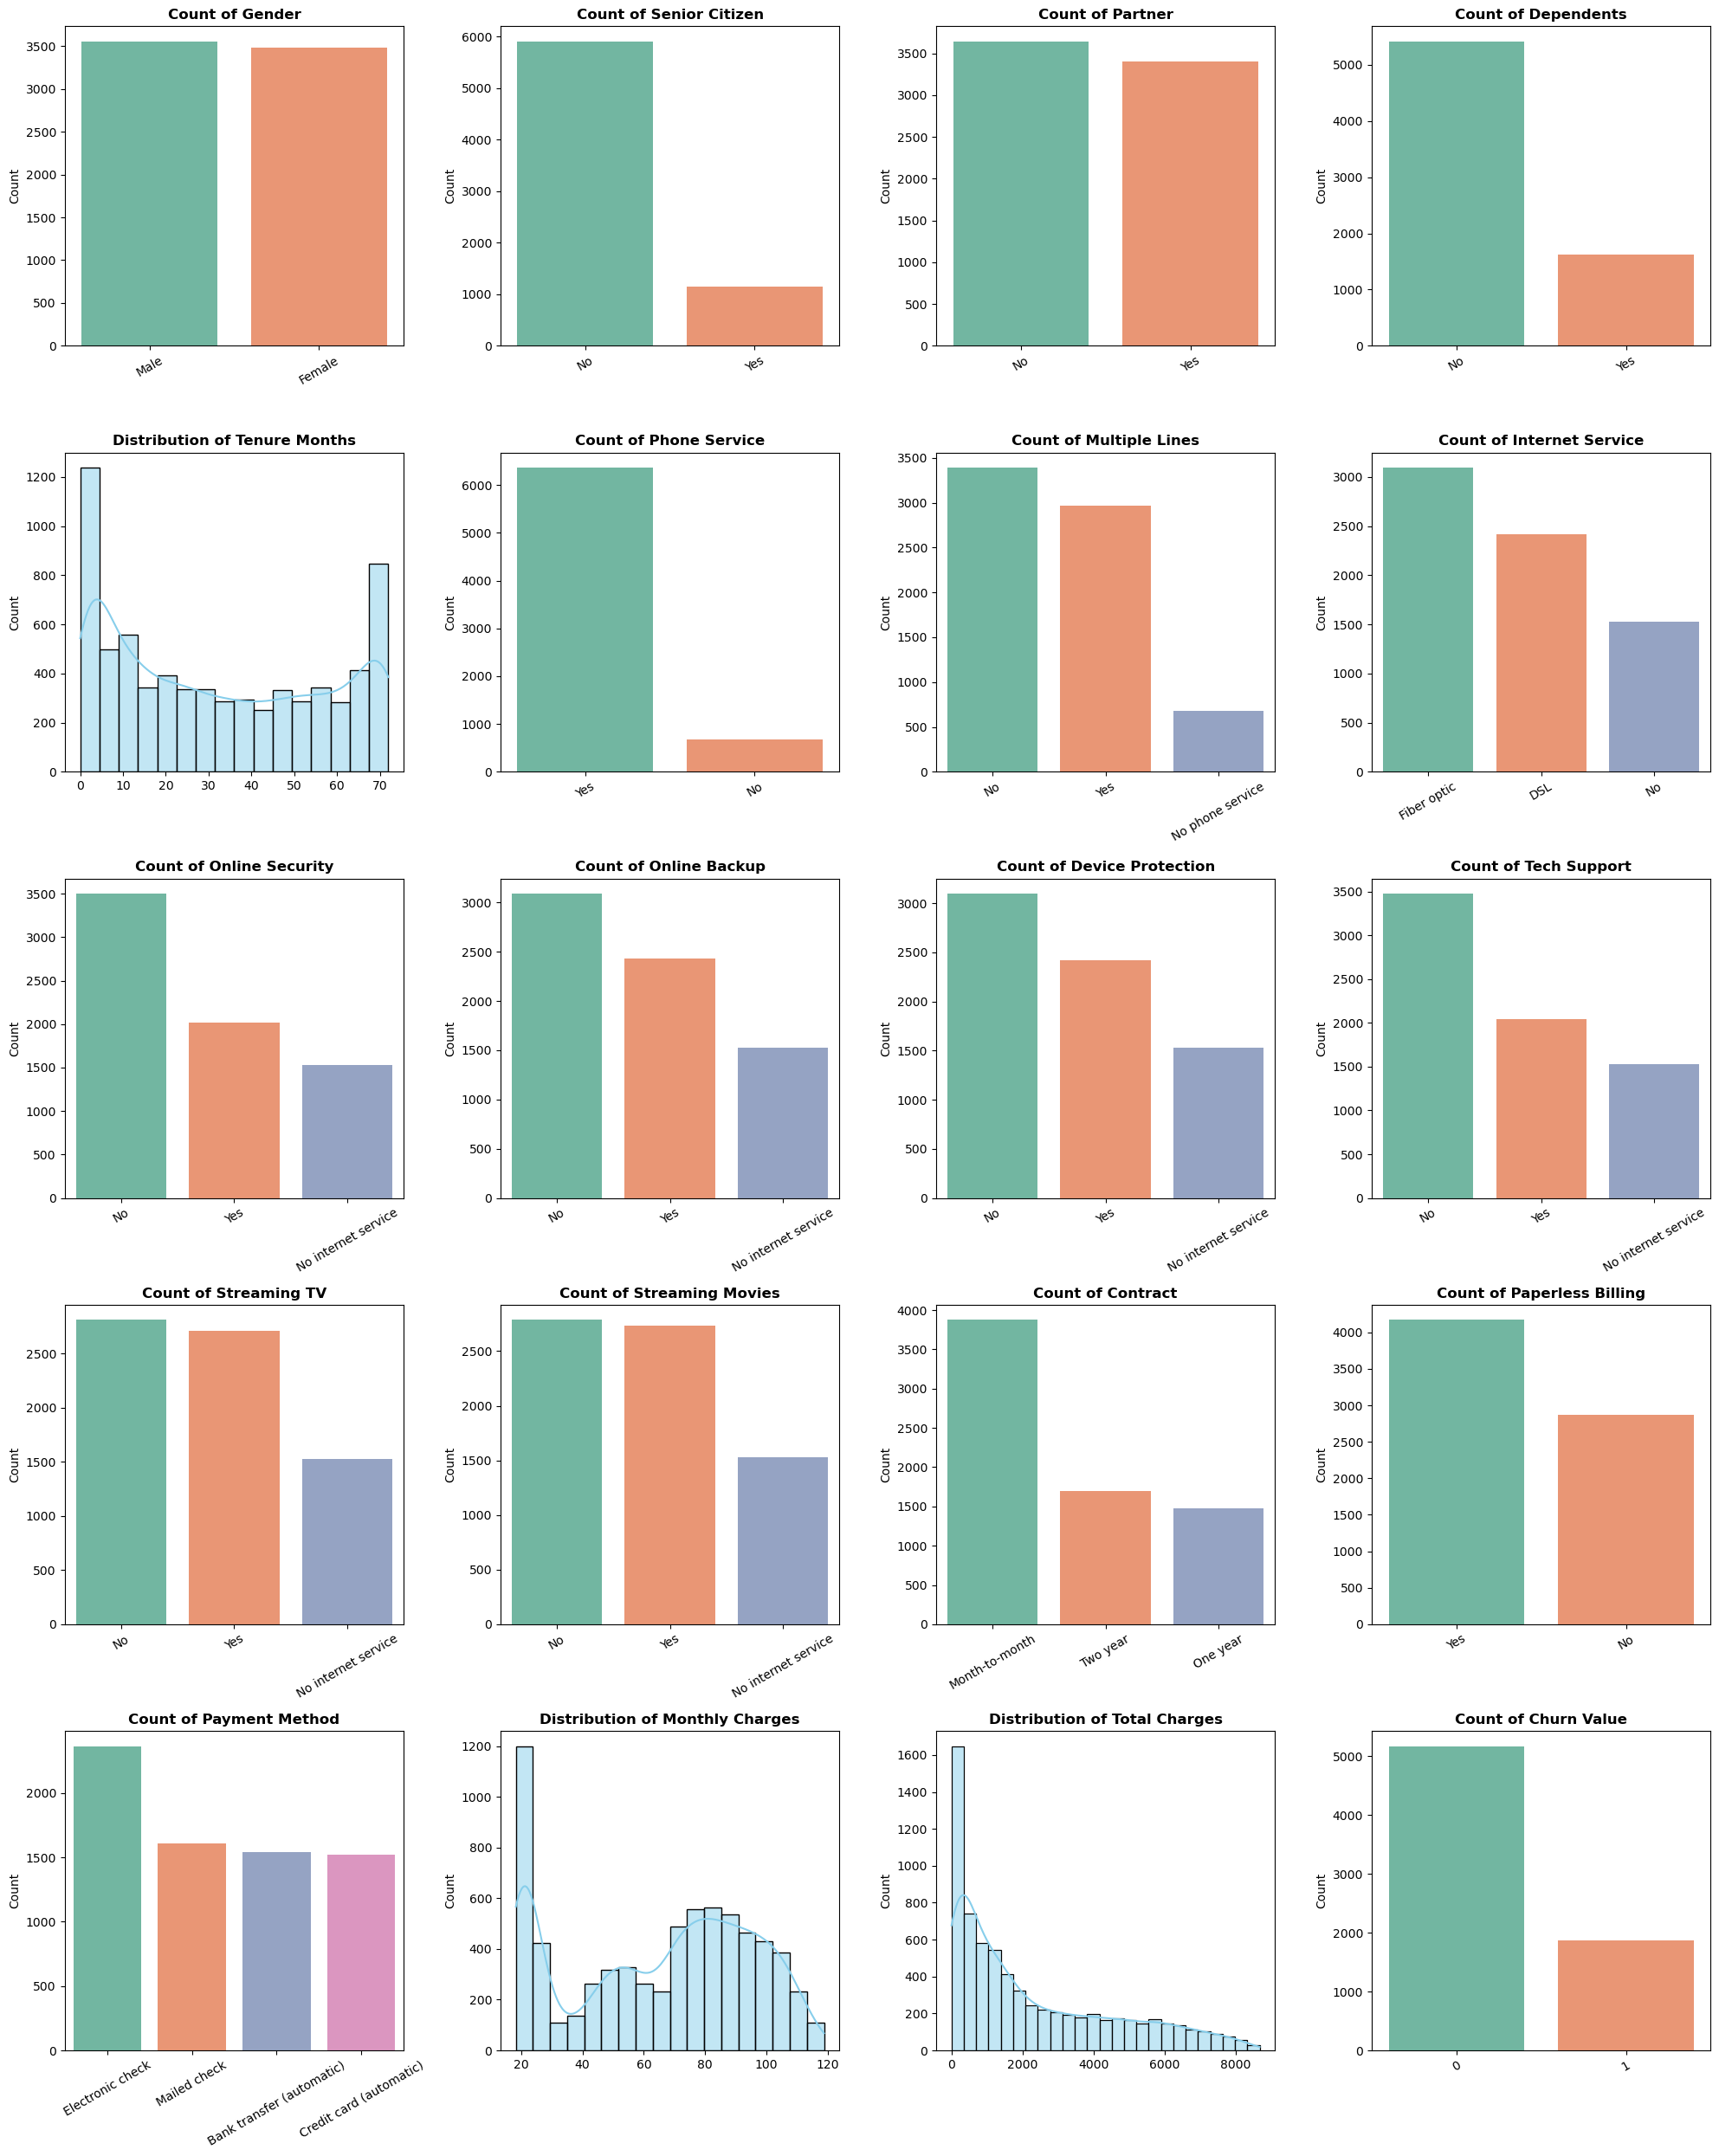

In [7]:

# 1. Clean 'Total Charges' and fill empty/null values with 0
# Using errors='coerce' turns the blank spaces into NaN, which we then fill with 0
df_predictive["Total Charges"] = pd.to_numeric(df_predictive["Total Charges"], errors='coerce').fillna(
    df_predictive["Tenure Months"] * df_predictive["Monthly Charges"]
)

# 2. Define columns to plot (exclude CustomerID and City)
columns_to_plot = [col for col in df_predictive.columns if col not in ['CustomerID', 'City']]

# 3. Set up a grid for the subplots (e.g., 4 columns wide)
num_cols = 4
num_rows = int(np.ceil(len(columns_to_plot) / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten() # Flatten to easily iterate through them

# 4. Loop through the columns and plot
for i, col in enumerate(columns_to_plot):
    # Check if the column is numerical (with many unique values) or categorical
    if pd.api.types.is_numeric_dtype(df_predictive[col]) and df_predictive[col].nunique() > 10:
        # Plot Histogram for continuous numerical features
        sns.histplot(data=df_predictive, x=col, kde=True, ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    else:
        # Plot Bar Chart (Countplot) for categorical features
        sns.countplot(data=df_predictive, x=col, ax=axes[i], palette='Set2', 
                      order=df_predictive[col].value_counts().index)
        axes[i].set_title(f'Count of {col}', fontsize=12, fontweight='bold')
        # Rotate x-labels slightly for better readability if the names are long
        axes[i].tick_params(axis='x', rotation=30)
        
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('')

# 5. Hide any extra empty subplots (if the grid size is larger than the number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

#### **Hot Encoding**

Handling data types and hot encoding

In [8]:
# 1. Fix Multiple Lines
df_predictive['Multiple Lines'] = df_predictive['Multiple Lines'].replace({'No phone service': 'No'})

# 2. Fix all Internet Add-on services
internet_addons = [
    'Online Security', 
    'Online Backup', 
    'Device Protection', 
    'Tech Support', 
    'Streaming TV', 
    'Streaming Movies'
]

for col in internet_addons:
    df_predictive[col] = df_predictive[col].replace({'No internet service': 'No'})

#1. customer id
df_predictive["CustomerID"] = df_predictive["CustomerID"].astype("object")
df_predictive["City"] = df_predictive["City"].astype(object)

# Numeric columns
df_predictive["Tenure Months"] = df_predictive["Tenure Months"].astype("int64")
df_predictive["Monthly Charges"] = df_predictive["Monthly Charges"].astype("float64")
df_predictive["Total Charges"] = pd.to_numeric(df_predictive["Total Charges"], errors="coerce").fillna(
    df_predictive["Tenure Months"] * df_predictive["Monthly Charges"]
)
df_predictive["Churn Value"] = df_predictive["Churn Value"].astype("int64")

# Binary columns: safely convert to 0/1 using replace
df_predictive["Gender"] = df_predictive["Gender"].replace({"Female": 0, "Male": 1}).astype("int64")
df_predictive["Senior Citizen"] = df_predictive["Senior Citizen"].replace({"No": 0, "Yes": 1}).astype("int64")
df_predictive["Partner"] = df_predictive["Partner"].replace({"No": 0, "Yes": 1}).astype("int64")
df_predictive["Dependents"] = df_predictive["Dependents"].replace({"No": 0, "Yes": 1}).astype("int64")
df_predictive["Phone Service"] = df_predictive["Phone Service"].replace({"No": 0, "Yes": 1}).astype("int64")
df_predictive["Paperless Billing"] = df_predictive["Paperless Billing"].replace({"No": 0, "Yes": 1}).astype("int64")


# One-hot encode multi-category columns with baseline established
columns_to_encode = [
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Payment Method"
]

df_predictive = pd.get_dummies(
    df_predictive,
    columns=columns_to_encode,
    dtype=int,
    drop_first=True
)

# Check result
df_predictive.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   CustomerID                              7043 non-null   object 
 1   City                                    7043 non-null   object 
 2   Gender                                  7043 non-null   int64  
 3   Senior Citizen                          7043 non-null   int64  
 4   Partner                                 7043 non-null   int64  
 5   Dependents                              7043 non-null   int64  
 6   Tenure Months                           7043 non-null   int64  
 7   Phone Service                           7043 non-null   int64  
 8   Paperless Billing                       7043 non-null   int64  
 9   Monthly Charges                         7043 non-null   float64
 10  Total Charges                           7043 non-null   float64
 11  Ch

In [9]:
#drop duplicate columns
df_predictive = df_predictive.drop_duplicates()

 #### **4.Feature Engineering**

Added 2 New columns 

1. Payment Method : High risk (Electronic cheque), medium (Mailed check) and low risk(Bank transfer and credit card )
2. Tenure groups: > New (>12 months), medium (1-2 years), and Long term (2 years+)

In [10]:
df.groupby("Payment Method")["Churn Value"].mean()  

Payment Method
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn Value, dtype: float64

In [11]:
# Feature Engineering: Payment Risk Category (Pulling from original df)
payment_risk_mapping = {
    'Electronic check': 'High Risk',
    'Mailed check': 'Medium Risk',
    'Bank transfer (automatic)': 'Low Risk',
    'Credit card (automatic)': 'Low Risk'
}

df_predictive['Payment Risk Category'] = df['Payment Method'].map(payment_risk_mapping)


In [12]:
# Feature Engineering: 3-Tier Tenure Groups
tenure_bins = [0, 12, 24, 100]  # 0-12 months, 13-24 months, 24+ months
tenure_labels = ['New', 'Medium', 'Long term']

df_predictive['Tenure Group'] = pd.cut(
    df_predictive['Tenure Months'], 
    bins=tenure_bins, 
    labels=tenure_labels, 
    include_lowest=True
)

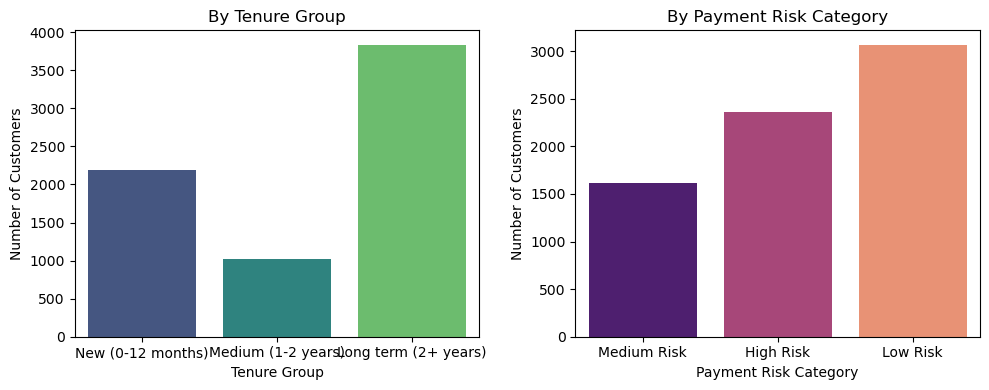

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Distribution of Tenure Groups
sns.countplot(
    data=df_predictive, 
    x='Tenure Group', 
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('By Tenure Group')
axes[0].set_xlabel('Tenure Group')
axes[0].set_ylabel('Number of Customers')

# Explicitly edit the x-axis labels for the Tenure Group plot
axes[0].set_xticklabels(['New (0-12 months)', 'Medium (1-2 years)', 'Long term (2+ years)'])

# Plot 2: Distribution of Payment Risk Categories
sns.countplot(
    data=df_predictive, 
    x='Payment Risk Category', 
    palette='magma',
    ax=axes[1]
)
axes[1].set_title('By Payment Risk Category')
axes[1].set_xlabel('Payment Risk Category')
axes[1].set_ylabel('Number of Customers')

# Automatically adjust spacing to prevent overlap
plt.tight_layout()
plt.show()

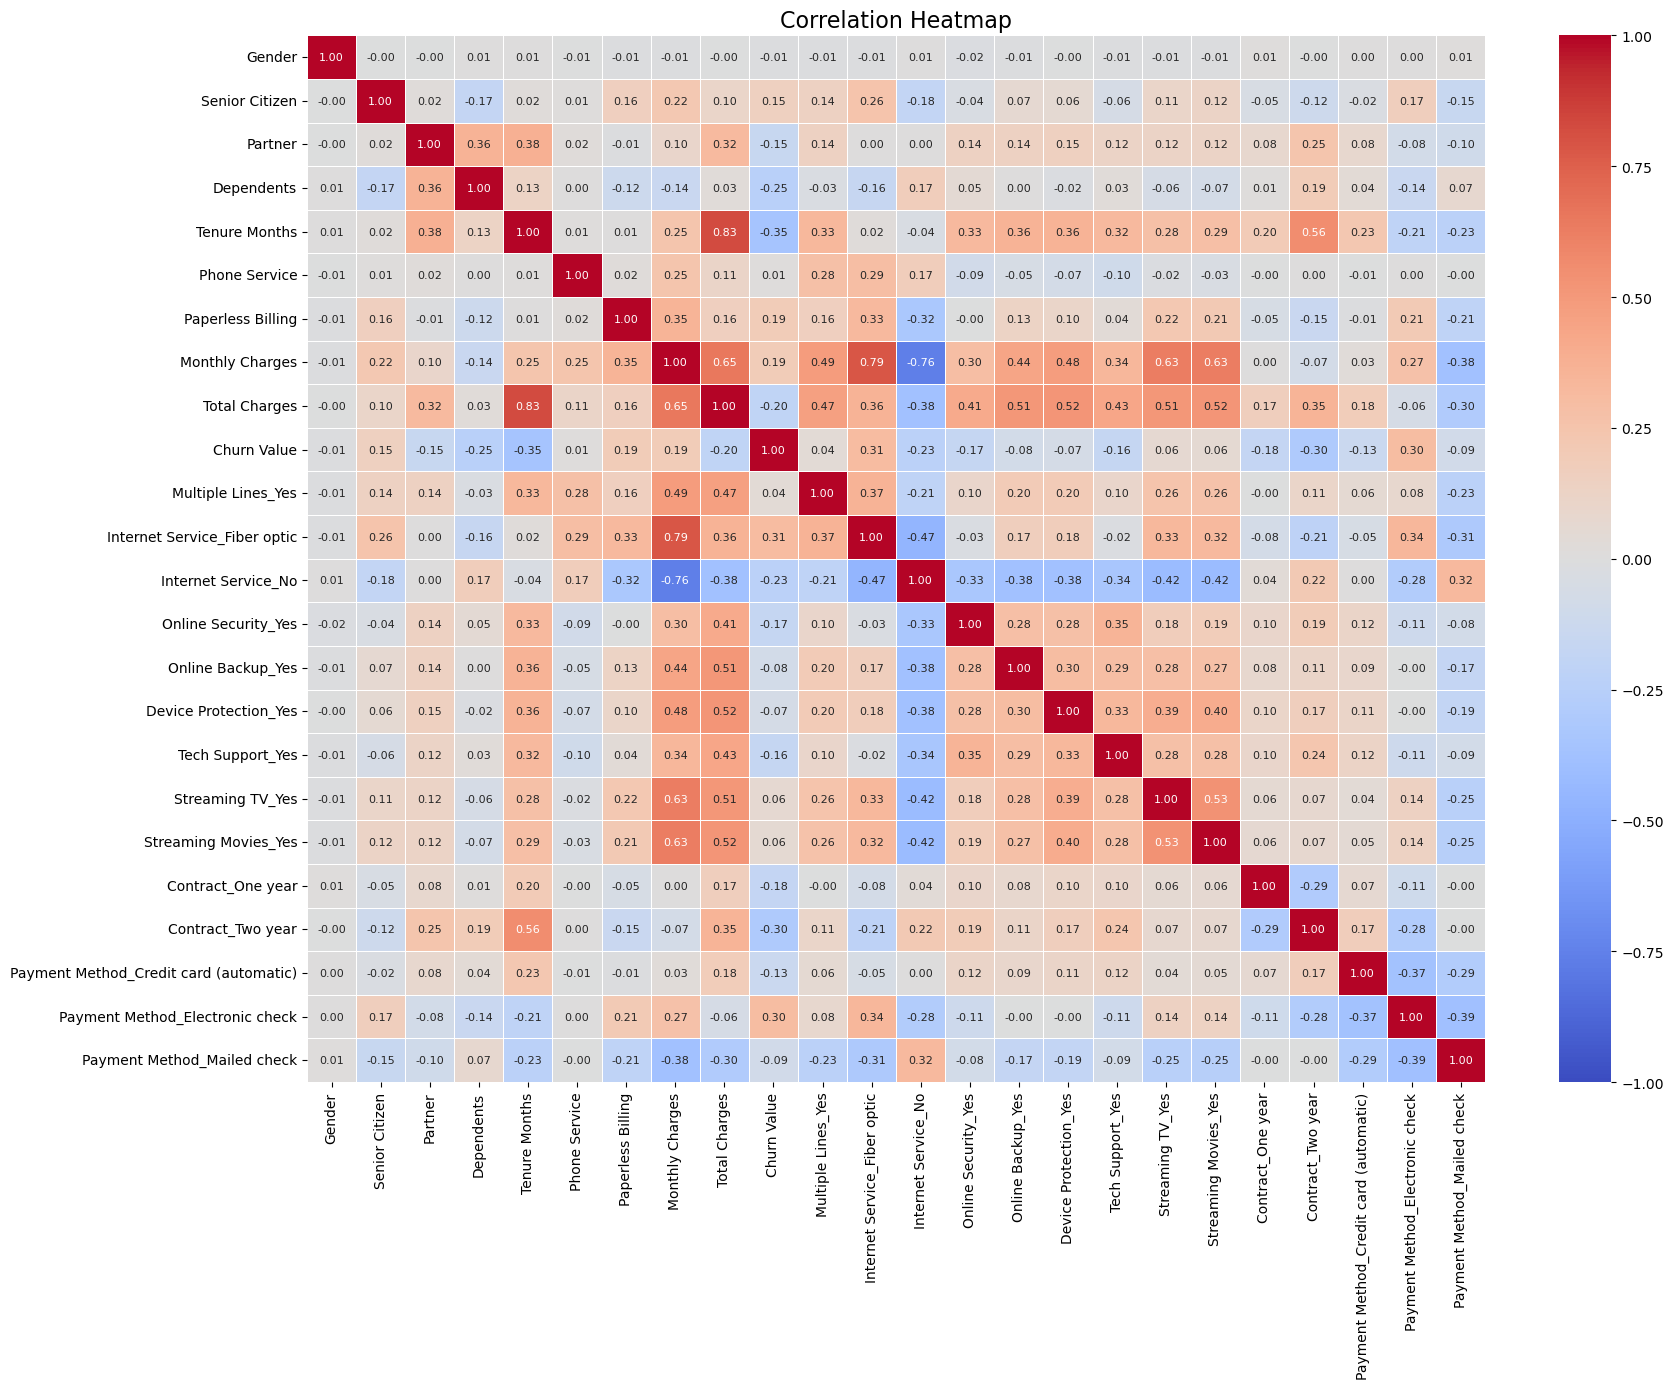

In [14]:
# 1. Define the engineered columns to exclude (only the ones you actually created)
engineered_cols = ['Tenure Group', 'Payment Risk Category']

# 2. Filter to keep only columns that actually exist in your dataframe
cols_to_drop = [col for col in engineered_cols if col in df_predictive.columns]

# 3. Create a temporary dataframe for correlation by dropping the engineered columns
df_heatmap = df_predictive.drop(columns=cols_to_drop)

# 4. Calculate the correlation matrix on the remaining numeric columns
corr_matrix = df_heatmap.corr(numeric_only=True)

# 5. Plot the heatmap with numbers displayed
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    annot=True, 
    fmt='.2f', 
    annot_kws={"size": 8},
    linewidths=0.5,
    vmin=-1, 
    vmax=1,
    center=0
)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

#### **5.Feature importance**

The features that seem most corelated are tenure 

Longer Tenure , contracts, no internet service and those with dependents are less likely to churn 
<br>Fiber optic users, Electronic cheque users and those with high monthly charges are more likely to churn


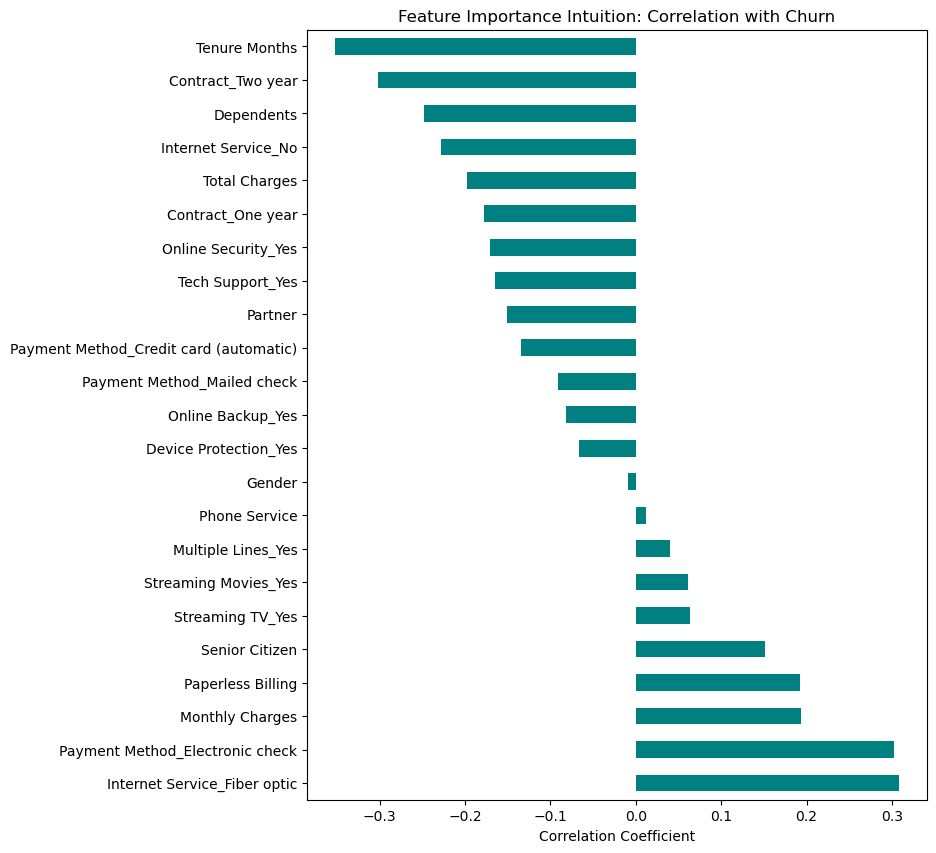

In [15]:
# Calculate how every feature correlates with Churn Value
churn_correlations = df_predictive.corr(numeric_only=True)['Churn Value'].sort_values(ascending=False)

# Plot the top 10 churn drivers and top 10 retention drivers
plt.figure(figsize=(8, 10))
churn_correlations.drop('Churn Value').plot(kind='barh', color='teal')
plt.title('Feature Importance Intuition: Correlation with Churn')
plt.xlabel('Correlation Coefficient')
plt.show()

In [16]:
df_predictive.head()

,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_Yes,Online Backup_Yes,Device Protection_Yes,Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Payment Risk Category,Tenure Group
0,3668-QPYBK,Los Angeles,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,Medium Risk,New
1,9237-HQITU,Los Angeles,0,0,0,1,2,1,1,70.70,151.65,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,High Risk,New
2,9305-CDSKC,Los Angeles,0,0,0,1,8,1,1,99.65,820.50,1,1,1,0,0,0,1,0,1,1,0,0,0,1,0,High Risk,New
3,7892-POOKP,Los Angeles,0,0,1,1,28,1,1,104.80,3046.05,1,1,1,0,0,0,1,1,1,1,0,0,0,1,0,High Risk,Long term
4,0280-XJGEX,Los Angeles,1,0,0,1,49,1,1,103.70,5036.30,1,1,1,0,0,1,1,0,1,1,0,0,0,0,0,Low Risk,Long term


Exporting with feature Engineered columns for sql analysis as cleaned_telco_churn_for_sql

In [17]:

df_predictive.to_csv('Datasets\\cleaned_telco_churn_predictive.csv', index=False)

Preparing dataset for ML by dropping city column as it has too many categories and feature engineered columns Payment Risk Category and Tenure Group (our dataset contains same information) as well as Total Charges(as it is corelated with tenure months and monthly charges)

In [18]:
# 1. Drop the City column and hot encode the engineered columns 
df_predictive = df_predictive.drop(columns=['CustomerID','City', 'Payment Risk Category', 'Tenure Group', 'Total Charges'], errors='ignore')


df_predictive.to_csv('Datasets\\cleaned_telco_churn_predictive.csv', index=False)
# Optional: Verify the final columns before moving to your ML notebook
df_predictive.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  7043 non-null   int64  
 1   Senior Citizen                          7043 non-null   int64  
 2   Partner                                 7043 non-null   int64  
 3   Dependents                              7043 non-null   int64  
 4   Tenure Months                           7043 non-null   int64  
 5   Phone Service                           7043 non-null   int64  
 6   Paperless Billing                       7043 non-null   int64  
 7   Monthly Charges                         7043 non-null   float64
 8   Churn Value                             7043 non-null   int64  
 9   Multiple Lines_Yes                      7043 non-null   int32  
 10  Internet Service_Fiber optic            7043 non-null   int32  
 11  In